# Credit Card Default Prediction

## 1. Problem Statement

One of the most significant financial risks for banks is credit card default. The bank that issued the credit card loses money when customers don't pay off their balances because it has more money owed to it. The dataset I picked comes from a real bank in Taiwan and has information on 30,000 credit card users. The bank's business problem is that it needs to figure out which customers are most likely to miss their next payment. Taiwan aggressively increased lending in the early 2000s. This caused credit card debt crisis of 2005-2006(Kang and Ma,2007).

As a data scientist, in this project I will be developing a machine learning model that predicts the probability of a customer defaulting on a payment in the coming month. The goal is whether the customer will not pay (1) or will pay (0) next month. The model will learn from features such as payment history and bill amounts to make this prediction.

This model aims to enable businesses to proactively identify high-risk customers and offer customized payment plans, reduce credit loss provisions by flagging risky accounts before default occurs, and optimize credit limit decisions.


Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [4]:
# import the libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score)
from sklearn.dummy import DummyClassifier

# set random seed so results are reproducible
SEED = 42
np.random.seed(SEED)

print("All libraries imported.")

All libraries imported.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# load the dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/UCI_Credit_Card.csv'
df = pd.read_csv(file_path)

# rename the target column so it's easier to type
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Shape: (30000, 25)

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Data Exploration

First I want to understand what the data looks like and check for any obvious problems before I start building the model.

In [6]:
# quick overview of the data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_0      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 non-null  float64
 20  PAY_AM

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


The dataset has 30,000 rows and 25 columns. There are no missing values
in any column. All columns are numerical either int64 or float64. Some columns like SEX, EDUCATION and MARRIAGE look categorical but they are stored as integers, so I'll need to keep that in mind later.

default
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.1%


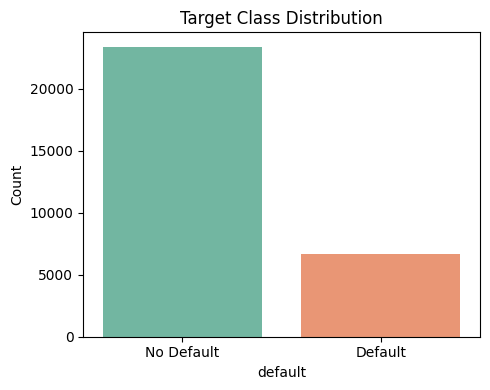

In [7]:
# check how many clients defaulted vs didn't
target_counts = df['default'].value_counts()
print(target_counts)
print(f"\nDefault rate: {target_counts[1] / len(df) * 100:.1f}%")

# plot it
plt.figure(figsize=(5, 4))
sns.countplot(x='default', data=df, palette='Set2')
plt.title('Target Class Distribution')
plt.xticks([0, 1], ['No Default', 'Default'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The data is imbalanced only about 22% of clients actually defaulted. This means accuracy is not a good metric here because the model could just predict "no default" every time and still get 78% accuracy. I'll use F1-score and AUC-ROC instead.

I considered using SMOTE to oversample the minority class, but decided to use `class_weight='balanced'` in the models instead. This way I don't have to change the training data and it avoids creating fake samples.

In [9]:
# check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# check for unusual values in the PAY columns
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
print("\nUnique values in PAY columns:")
for col in pay_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

# EDUCATION has some undocumented values
print("\nEDUCATION value counts:")
print(df['EDUCATION'].value_counts().sort_index())

# MARRIAGE has an undocumented 0 value
print("\nMARRIAGE value counts:")
print(df['MARRIAGE'].value_counts().sort_index())

Missing values per column:
ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

Unique values in PAY columns:
  PAY_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_2: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_3: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_4: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3),

I did notice some data quality issues, EDUCATION has values 0, 5 and 6 that aren't explained in the documentation, and MARRIAGE has a 0 value that also isn't documented. I'll group these into the 'Others' category later.

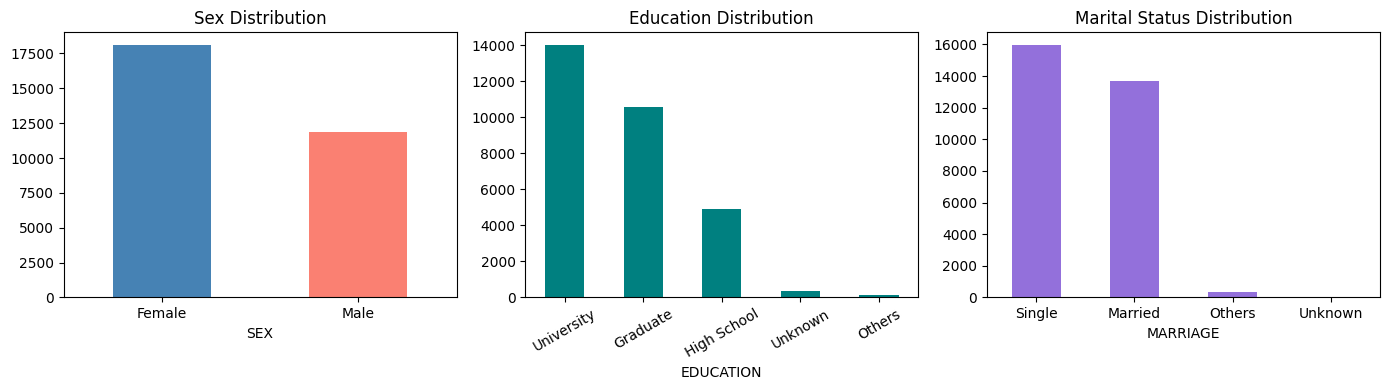

In [10]:
# plot the demographic columns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# sex
df['SEX'].map({1:'Male', 2:'Female'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue','salmon'], rot=0)
axes[0].set_title('Sex Distribution')

# education
edu_map = {1:'Graduate', 2:'University', 3:'High School', 4:'Others', 0:'Unknown', 5:'Unknown', 6:'Unknown'}
df['EDUCATION'].map(edu_map).value_counts().plot(
    kind='bar', ax=axes[1], rot=30, color='teal')
axes[1].set_title('Education Distribution')

# marriage
mar_map = {1:'Married', 2:'Single', 3:'Others', 0:'Unknown'}
df['MARRIAGE'].map(mar_map).value_counts().plot(
    kind='bar', ax=axes[2], rot=0, color='mediumpurple')
axes[2].set_title('Marital Status Distribution')

plt.tight_layout()
plt.show()

Looking at the demographic charts, most clients are female and have a university education. These features probably won't be as useful as the payment history columns but I'll keep them in the model for now.

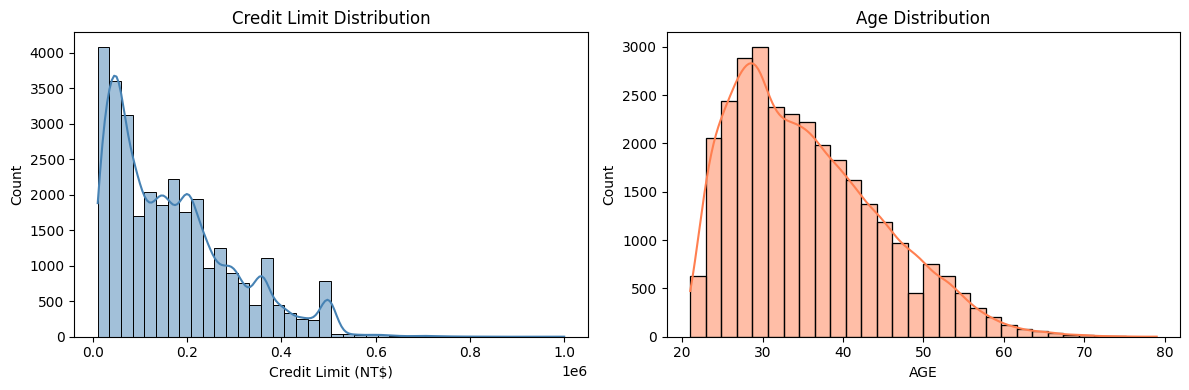

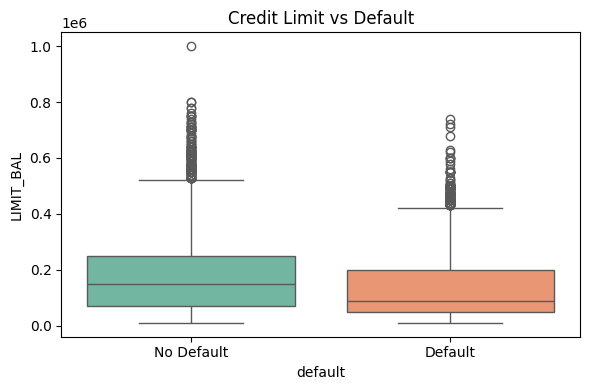

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['LIMIT_BAL'], bins=40, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Credit Limit Distribution')
axes[0].set_xlabel('Credit Limit (NT$)')

sns.histplot(df['AGE'], bins=30, ax=axes[1], color='coral', kde=True)
axes[1].set_title('Age Distribution')

plt.tight_layout()
plt.show()

# compare credit limit between defaulters and non-defaulters
plt.figure(figsize=(6, 4))
sns.boxplot(x='default', data=df, y='LIMIT_BAL', palette='Set2')
plt.xticks([0,1], ['No Default', 'Default'])
plt.title('Credit Limit vs Default')
plt.tight_layout()
plt.show()


I can see that clients who defaulted tend to have lower credit limits
and the distribution is skewed to the right. Age looks mostly in the
30s. Looking at the boxplot, clients who defaulted tend to have lower credit limits, either because the bank gave lower limits to riskier customers or because lower-limit clients are more financially vulnerable This suggests LIMIT_BAL could be a useful feature even though its correlation with the target is low.

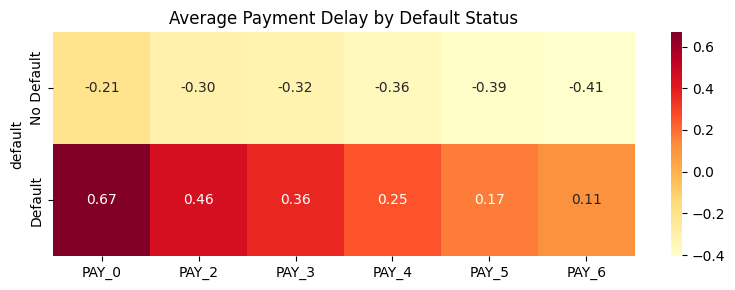

In [12]:
# look at average payment delay by default status
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
pay_avg = df.groupby('default')[pay_cols].mean()

plt.figure(figsize=(8, 3))
sns.heatmap(pay_avg, annot=True, fmt='.2f', cmap='YlOrRd',
            yticklabels=['No Default', 'Default'])
plt.title('Average Payment Delay by Default Status')
plt.tight_layout()
plt.show()

Clients who didn't default have negative
payment delay values across all six months, meaning they paid on time
or early. Clients who defaulted have consistently positive values,
meaning they were late. The most recent month (PAY_0) shows the biggest
difference between the two groups, so I expect it to be one of the most
important features in the model.

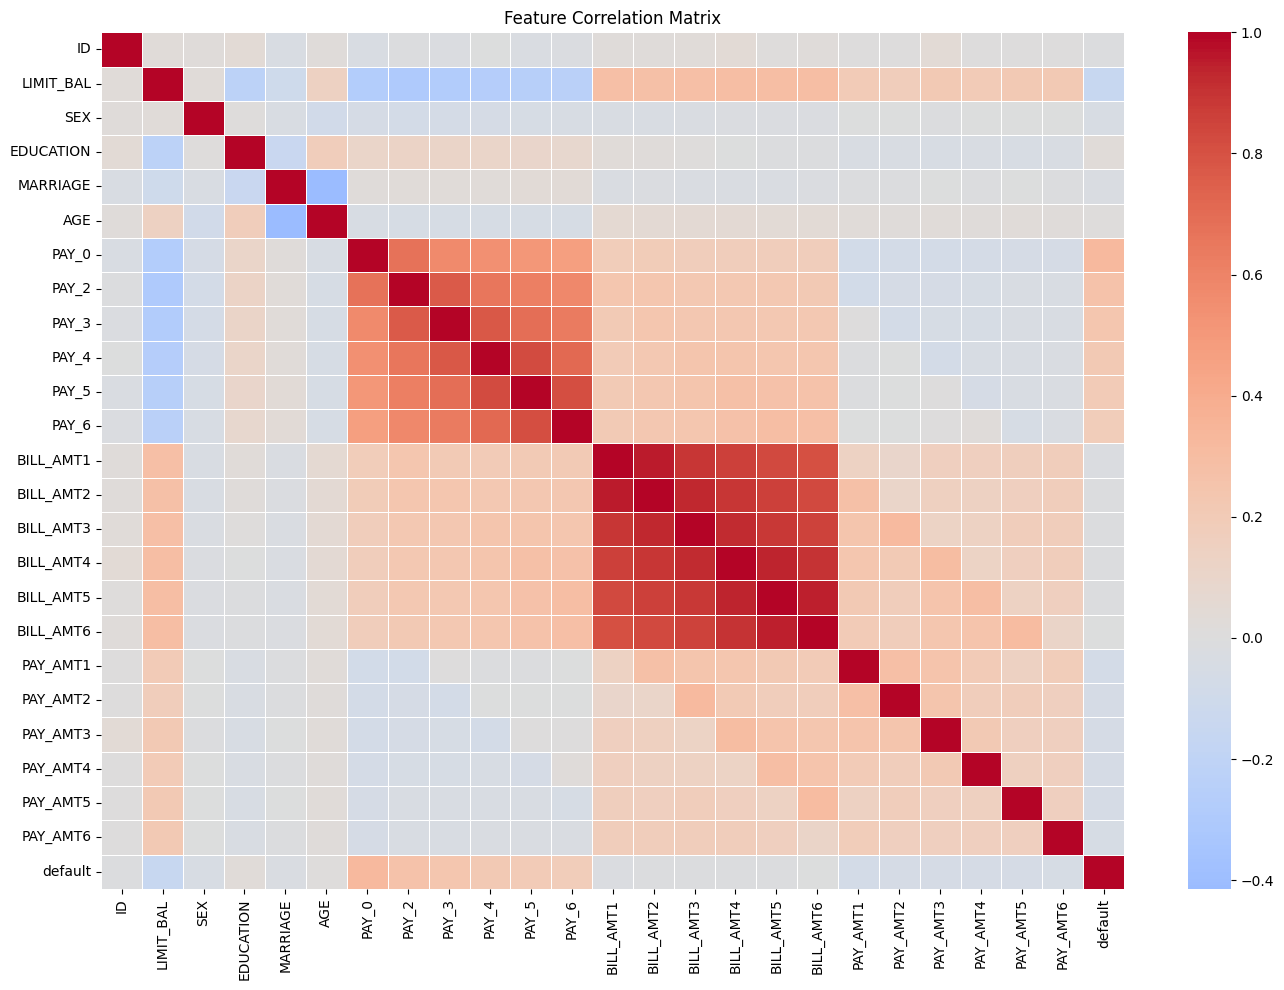

Top correlations with target:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
Name: default, dtype: float64


In [13]:
# correlation matrix
corr = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# which features are most correlated with the target?
print('Top correlations with target:')
print(corr['default'].abs().sort_values(ascending=False)[1:11])



The PAYMENT columns have the highest correlation with the target,
PAY_0 has the strongest correlation at 0.32.

The BILL_AMOUNT columns have very high correlations with each other; they essentially say the same thing, so I'll try to combine them into a single feature.

LIMIT_BAL has a low correlation with the target (0.15), but the earlier box plot showed that those who default tend to have lower credit limits, so it's still a useful feature. Overall, no feature has a very strong correlation with the target, which might lead us to think that a simple linear model would probably not be sufficient.

## 3. Preprocessing & Feature Engineering

In [14]:
# drop the target and the ID column (ID is just a row number, not useful)
X = df.drop(columns=['default', 'ID'])
y = df['default']

# split into train and test — I'm doing this before preprocessing to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"\nTrain default rate: {y_train.mean():.3f}")
print(f"Test default rate:  {y_test.mean():.3f}")

Train size: 24000
Test size:  6000

Train default rate: 0.221
Test default rate:  0.221


I split the data into training and test sets before doing any preprocessing. This is important to avoid data leakage  if I scaled or cleaned the full dataset first, information from the test set would sneak into the training process.

I also dropped the ID column because it's just a row number and has no useful information for the model.

In [15]:
# fix the undocumented values in EDUCATION and MARRIAGE
# group 0, 5, 6 into 4 (Others)
X_train['EDUCATION'] = X_train['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
X_test['EDUCATION']  = X_test['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# group 0 into 3 (Others)
X_train['MARRIAGE'] = X_train['MARRIAGE'].replace({0: 3})
X_test['MARRIAGE']  = X_test['MARRIAGE'].replace({0: 3})

print("EDUCATION unique values:", sorted(X_train['EDUCATION'].unique()))
print("MARRIAGE unique values: ", sorted(X_train['MARRIAGE'].unique()))

EDUCATION unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE unique values:  [np.int64(1), np.int64(2), np.int64(3)]


The EDUCATION values 0, 5 and 6 are not in the original documentation so I grouped them into category 4 (Others). I did the same for MARRIAGE value 0. This way the model won't treat these mystery values as something meaningful.

In [16]:
# create new features
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# average payment delay
X_train['AVG_PAY_DELAY'] = X_train[pay_cols].mean(axis=1)
X_test['AVG_PAY_DELAY']  = X_test[pay_cols].mean(axis=1)

# average bill amount
X_train['AVG_BILL_AMT'] = X_train[bill_cols].mean(axis=1)
X_test['AVG_BILL_AMT']  = X_test[bill_cols].mean(axis=1)

# average amount paid
X_train['AVG_PAY_AMT'] = X_train[pay_amt_cols].mean(axis=1)
X_test['AVG_PAY_AMT']  = X_test[pay_amt_cols].mean(axis=1)

# how much of the bill was paid (low = financial stress)
X_train['PAY_RATIO'] = X_train['AVG_PAY_AMT'] / (X_train['AVG_BILL_AMT'] + 1)
X_test['PAY_RATIO']  = X_test['AVG_PAY_AMT']  / (X_test['AVG_BILL_AMT']  + 1)

# credit utilization
X_train['CREDIT_UTIL'] = X_train['AVG_BILL_AMT'] / (X_train['LIMIT_BAL'] + 1)
X_test['CREDIT_UTIL']  = X_test['AVG_BILL_AMT']  / (X_test['LIMIT_BAL']  + 1)

print("New features added:", ['AVG_PAY_DELAY', 'AVG_BILL_AMT', 'AVG_PAY_AMT', 'PAY_RATIO', 'CREDIT_UTIL'])
print(f"Total features: {X_train.shape[1]}")

New features added: ['AVG_PAY_DELAY', 'AVG_BILL_AMT', 'AVG_PAY_AMT', 'PAY_RATIO', 'CREDIT_UTIL']
Total features: 28


I created 5 new features that I think could help the model. AVG_PAY_DELAY is the average payment delay over 6 months. PAY_RATIO shows how much of the bill the client actually paid if this is low it might mean they're in financial trouble. CREDIT_UTIL shows how much of the credit limit they're using.

In [17]:
# some of the new features can produce inf values when dividing by zero
# replace inf with NaN and fill with the column mean from the training set
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

train_means = X_train.mean()
X_train = X_train.fillna(train_means)
X_test  = X_test.fillna(train_means)

print('NaN check — Train:', X_train.isnull().sum().sum())
print('NaN check — Test: ', X_test.isnull().sum().sum())

NaN check — Train: 0
NaN check — Test:  0


Some of the new features I created involve division like PAY_RATIO, which can cause infinity values if the bill amount is zero. I replaced those with NaN and then filled them with the column mean from the training set. I made sure to only use the training set mean to avoid leakage.

In [18]:
# scale the numerical columns
# I'm not scaling SEX, EDUCATION, MARRIAGE because they are categorical
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
num_cols = [c for c in X_train.columns if c not in cat_cols]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Scaling done.")
print(f"Scaled {len(num_cols)} columns.")

Scaling done.
Scaled 25 columns.



I used StandardScaler to scale all the numerical columns to the same level. I only applied the scaler to the training set and then to the test set. If I had applied it to both, the test data would have affected the scaling, and that would have been a kind of data leak. I left the Gender, Education, and Marriage columns as they were because tree-based models don't need scaling.

## 4. Model Training

In [19]:
from sklearn.tree import DecisionTreeClassifier

# I will train each model separately and compare them
results = []

# 1. Dummy baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
y_prob = dummy.predict_proba(X_test)[:, 1]
results.append({'Model': 'Dummy (Baseline)', 'F1': round(f1_score(y_test, y_pred), 4), 'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)})

# 2. Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]
results.append({'Model': 'Logistic Regression', 'F1': round(f1_score(y_test, y_pred), 4), 'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)})

# 3. Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]
results.append({'Model': 'Decision Tree', 'F1': round(f1_score(y_test, y_pred), 4), 'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)})

# 4. Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
results.append({'Model': 'Random Forest', 'F1': round(f1_score(y_test, y_pred), 4), 'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)})

# 5. Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]
results.append({'Model': 'Gradient Boosting', 'F1': round(f1_score(y_test, y_pred), 4), 'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)})

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
print(results_df.to_string(index=False))


              Model     F1  AUC-ROC
  Gradient Boosting 0.4746   0.7816
      Random Forest 0.4441   0.7593
Logistic Regression 0.4642   0.7096
      Decision Tree 0.3853   0.6055
   Dummy (Baseline) 0.0000   0.5000



I trained 5 different models to see which one works best. I used
class_weight='balanced' where possible to help with the class imbalance.
I'm comparing them by AUC-ROC because it works well for imbalanced datasets.

Looking at the results, Gradient Boosting has the best AUC-ROC (0.7816)
followed by Random Forest (0.7593). The Dummy baseline gets 0.5 which
is basically random guessing, so anything above that is a good sign.
Decision Tree has a lower AUC-ROC (0.6055) which suggests it might be
overfitting. I'll go with Gradient Boosting for hyperparameter tuning.

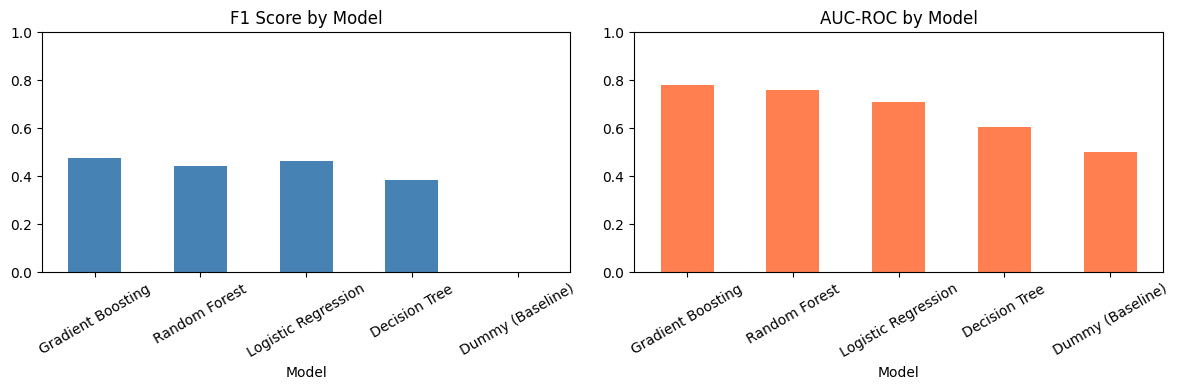

In [20]:
# plot the results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df.plot(x='Model', y='F1', kind='bar', ax=axes[0],
                color='steelblue', rot=30, legend=False)
axes[0].set_title('F1 Score by Model')
axes[0].set_ylim(0, 1)

results_df.plot(x='Model', y='AUC-ROC', kind='bar', ax=axes[1],
                color='coral', rot=30, legend=False)
axes[1].set_title('AUC-ROC by Model')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


Looking at the bar charts, Gradient Boosting has the best AUC-ROC
so I'll use that as my final model. Decision Tree had a decent F1  but a much lower AUC-ROC (0.60). Logistic Regression is surprisingly close to Random Forest on  AUC-ROC, which shows it's a decent baseline. The Dummy model gets  0.5 on AUC-ROC which is basically random guessing, so at least all the real models beat that.

In [21]:
# I will manually try a few different hyperparameter combinations for Gradient Boosting

from sklearn.metrics import roc_auc_score, f1_score

print("Testing different hyperparameter combinations...\n")

# Try different depths and learning rates
best_score = 0
best_model = None

for depth in [3, 4, 5]:
    for lr in [0.05, 0.1]:
        model = GradientBoostingClassifier(
            n_estimators=100,
            max_depth=depth,
            learning_rate=lr,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        score = roc_auc_score(y_test, y_prob)
        print(f"max_depth={depth}, learning_rate={lr} → AUC-ROC: {score:.4f}")

        if score > best_score:
            best_score = score
            best_model = model

print(f"\nBest AUC-ROC: {best_score:.4f}")

Testing different hyperparameter combinations...

max_depth=3, learning_rate=0.05 → AUC-ROC: 0.7818
max_depth=3, learning_rate=0.1 → AUC-ROC: 0.7816
max_depth=4, learning_rate=0.05 → AUC-ROC: 0.7820
max_depth=4, learning_rate=0.1 → AUC-ROC: 0.7806
max_depth=5, learning_rate=0.05 → AUC-ROC: 0.7820
max_depth=5, learning_rate=0.1 → AUC-ROC: 0.7788

Best AUC-ROC: 0.7820



I tested 6 different combinations of max_depth and learning_rate
while keeping n_estimators fixed at 100. The best AUC-ROC was
0.7820. The scores are all very close to each other, so Gradient Boosting seems to be able to handle these parameter choices well. I'll go with the best scoring model for the
final evaluation.

I chose to do this manually instead of using RandomizedSearchCV because I only had 6 combinations to test, so it was easy enough to just try them all and see which one gave the best AUC-ROC.

## 5. Model Assessment

In [22]:
# evaluate the best model on the test set
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

print("=== Final Model Performance ===\n")
print(classification_report(y_test, y_pred_final,
                             target_names=['No Default', 'Default']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_final):.4f}")

=== Final Model Performance ===

              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.67      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

AUC-ROC: 0.7820




Although the model has an 82% accuracy rate, the recall for the default class is 0.37. It misses 63% of the actual defaults.

The area we're primarily trying to improve is that we're failing to catch many of the things we try to catch without the default.

The precision value (0.67) indicates that we're getting two-thirds of the correct marks. The AUC-ROC of 0.78 is acceptable but definitely needs improvement.

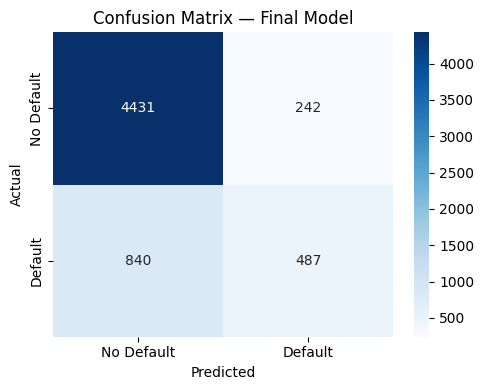

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix — Final Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

The model correctly identified 4431 non-defaulters and 487 actual defaulters.
840(FN) real defaulters these are the False Negatives and they are the most costly group, 242(FP) less serious  worst case the bank contacts them unnecessarily.

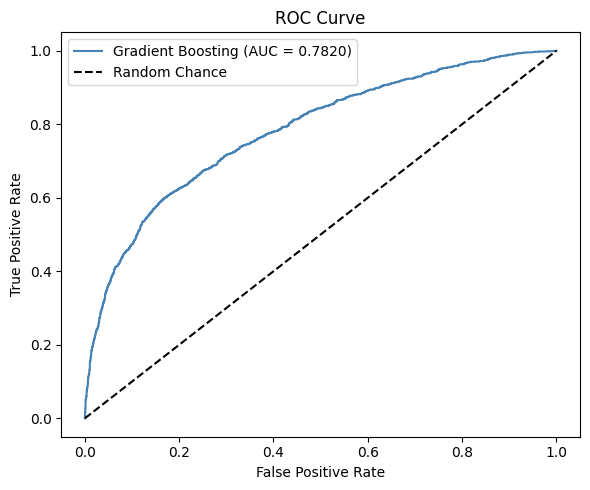

In [24]:
# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue',
         label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_final):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

 The AUC of 0.7820 means if I gave the model a random defaulter and a random non-defaulter, it would correctly rank the defaulter as riskier
about 78% of the time. It's not perfect but it's a reasonable
result for this kind of problem.

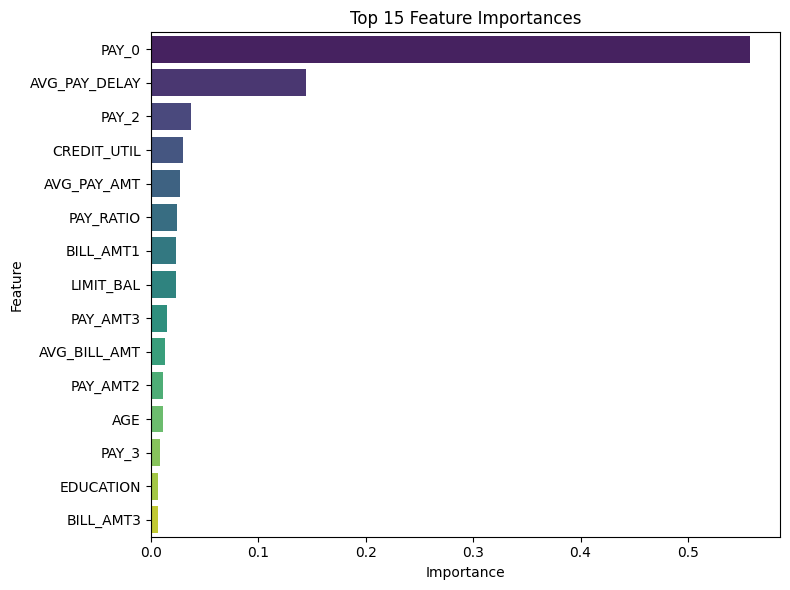

In [25]:
# feature importance — which features did the model rely on most?
feature_names = X_train.columns.tolist()
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

PAY_0 is by far the most important feature, which makes sense, recent payment delays are the strongest sign that someone  might default. AVG_PAY_DELAY, which is one of the features I created, also shows up second which is a good sign. Demographic features like age or education don't appear in the top 15 at all.

## 6. Final Discussion

Gradient Boosting was the best model with AUC-ROC of 0.7820 and the engineered features like AVG_PAY_DELAY and CREDIT_UTIL seemed to help. The biggest limitation is the low recall for defaulters (0.37), the model misses most of them. class_weight='balanced' helped but wasn't enough. The data also only comes from one Taiwanese bank in 2005 so it might not generalise well. I would recommend using this as an early warning system rather than a final decision tool. The model is a black box so individual predictions are hard to explain, which could be a problem in a regulated environment. I wouldn't deploy it yet, I'd want to improve recall first and test it on more recent data.

## References

Yeh, I.-C. and Lien, C.-H. (2009) 'The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients', *Expert Systems with Applications*, 36(2), pp. 2473–2480.

UCI Machine Learning Repository (2016) *Default of credit card clients dataset*. Available at: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset (Accessed: 25 March 2026).

Kang, T. and Ma, G. (2007) 'Recent episodes of credit card distress in Asia', BIS Quarterly Review, June, pp. 1–14. Available at: https://www.bis.org/repofficepubl/arpresearch_fs_200706.01.pdf (Accessed: 26 March 2026).